# V1 evaluation

This notebook evaluates on (`v1_best.pt`)


In [1]:
import contextlib
import copy
import io
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from PIL import Image
from torch.utils.data import DataLoader

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'pyproject.toml').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

from src.config import load_config
from src.data_loader.nuscenes_front_loader import NuScenesFrontLoader, collate_fn
from src.evaluation.evaluate import run_evaluation
from src.evaluation.metrics import PedestrianDetectionMetrics
from src.model.detector import CameraRadarDetector
from src.model.postprocess import CenterNetPostProcessor
from src.utils import resolve_path, select_device

plt.style.use('seaborn-v0_8-whitegrid')
torch.manual_seed(42)

config = load_config()
evaluation_config = config['evaluation']
device = select_device(evaluation_config['device'])
checkpoint_path = resolve_path(evaluation_config['checkpoint'])

print(f'Project root: {PROJECT_ROOT}')
print(f'Device: {device}')
print(f'Checkpoint: {checkpoint_path}')


Project root: /Users/williamkuo/Desktop/imec
Device: mps
Checkpoint: /Users/williamkuo/Desktop/imec/checkpoints/v1_best.pt


# Config used in v1

In [2]:
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
checkpoint_config = checkpoint.get('config', {})

experiment_summary = pd.DataFrame(
    {
        'Value': [
            config['camera_channel'],
            ', '.join(config['radar']['channels']),
            config['radar']['nsweeps'],
            str(config['image_size']),
            checkpoint.get('epoch'),
            checkpoint_config.get('train', {}).get('num_samples'),
            evaluation_config['split'],
            evaluation_config['score_threshold'],
        ]
    },
    index=[
        'Camera channel',
        'Radar channels',
        'Radar sweeps',
        'Input image size',
        'Selected epoch',
        'Training sample limit',
        'Evaluation split',
        'AP candidate score threshold',
    ],
)
experiment_summary


,Value
Camera channel,CAM_FRONT
Radar channels,RADAR_FRONT
Radar sweeps,5
Input image size,"(640, 360)"
Selected epoch,98
Training sample limit,None
Evaluation split,mini_val
AP candidate score threshold,0.001


# 2. mini-validation evaluation


In [3]:
validation_log = io.StringIO()
with contextlib.redirect_stdout(validation_log):
    validation_results = run_evaluation(copy.deepcopy(config))


,Metric,Value
0,AP50,0.2371
1,AP75,0.0432
2,mAP50:95,0.0863
3,mAP small,0.0503
4,mAP medium,0.1740
5,Precision@0.1,0.3930
6,Recall@0.1,0.3010


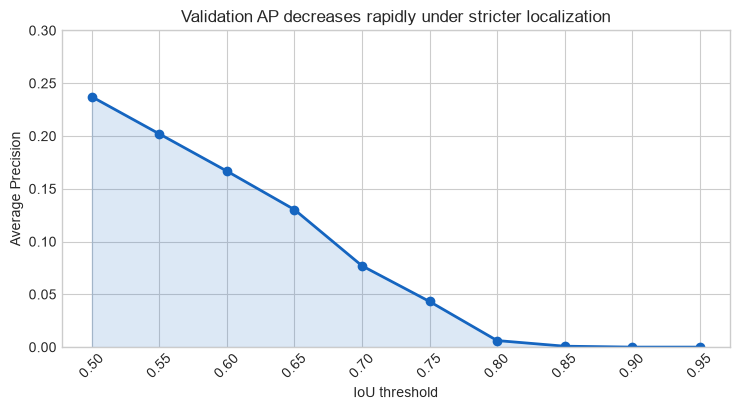

In [4]:
validation_table = pd.DataFrame(
    {
        'Metric': [
            'AP50', 'AP75', 'mAP50:95', 'mAP small', 'mAP medium',
            'Precision@0.1', 'Recall@0.1',
        ],
        'Value': [
            validation_results['ap50'],
            validation_results['ap75'],
            validation_results['map_50_95'],
            validation_results['map_small'],
            validation_results['map_medium'],
            validation_results['precision'],
            validation_results['recall'],
        ],
    }
)
display(validation_table.style.format({'Value': '{:.4f}'}))

iou_thresholds = [float(value) for value in validation_results['ap_by_iou']]
ap_values = list(validation_results['ap_by_iou'].values())

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(iou_thresholds, ap_values, marker='o', linewidth=2, color='#1565c0')
ax.fill_between(iou_thresholds, ap_values, alpha=0.15, color='#1565c0')
ax.set(
    title='Validation AP decreases rapidly under stricter localization',
    xlabel='IoU threshold',
    ylabel='Average Precision',
    xticks=iou_thresholds,
    ylim=(0.0, max(0.30, max(ap_values) * 1.15)),
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Qualitative predictions

Ground-truth boxes are red and predictions with score at least 0.1 are green. These examples show both missed pedestrians and localization errors.


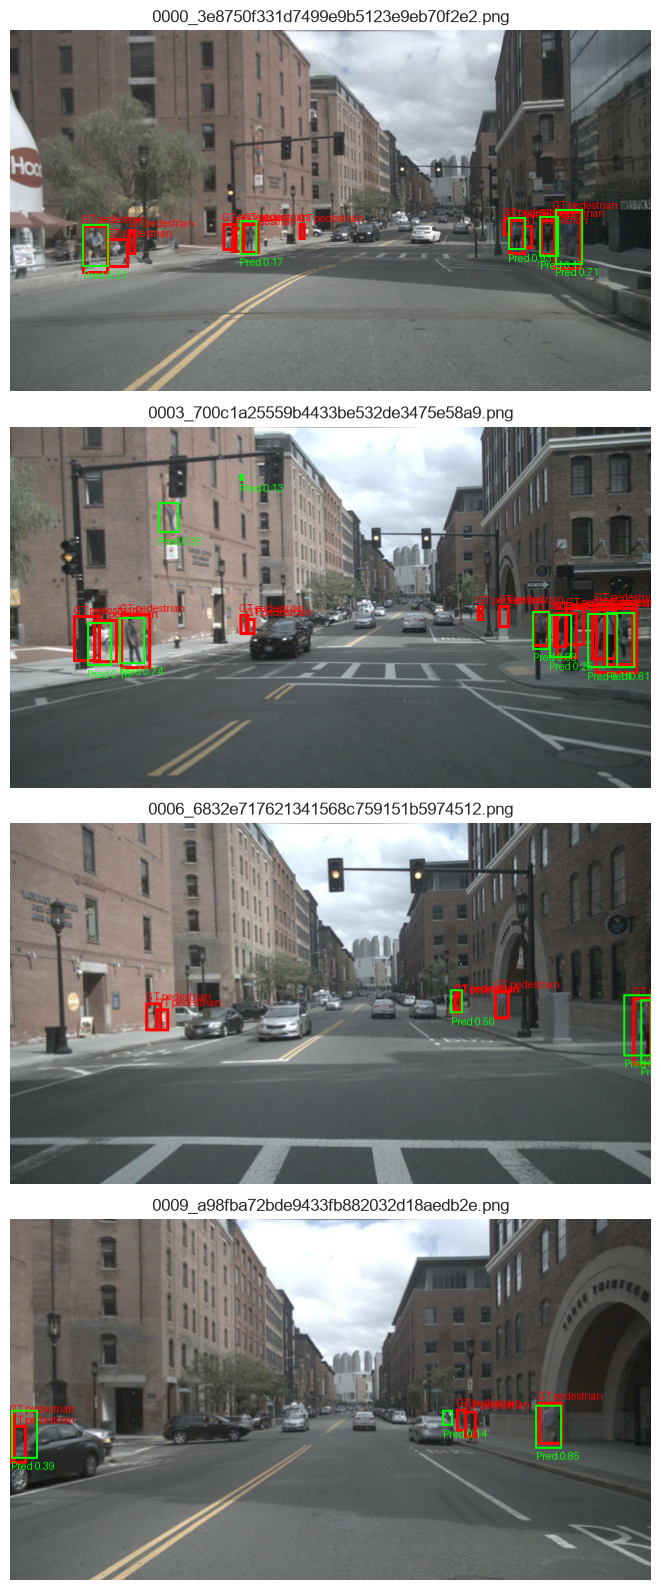

In [5]:
visualization_directory = resolve_path(evaluation_config['output_dir']) / 'visualizations'
visualization_paths = sorted(visualization_directory.glob('*.png'))

selected_indices = np.linspace(
    0, len(visualization_paths) - 1, min(4, len(visualization_paths)), dtype=int
)
selected_paths = [visualization_paths[index] for index in selected_indices]
fig, axes = plt.subplots(len(selected_paths), 1, figsize=(12, 4 * len(selected_paths)))
axes = np.atleast_1d(axes)
for ax, path in zip(axes, selected_paths):
    ax.imshow(Image.open(path))
    ax.set_title(path.name)
    ax.axis('off')
plt.tight_layout()
plt.show()


## 3. Generalization analysis


In [6]:
training_evaluation_config = copy.deepcopy(config)
training_evaluation_config['evaluation'].update(
    {
        'split': 'mini_train',
        'num_samples': None,
        'save_visualizations': False,
    }
)

training_log = io.StringIO()
with tempfile.TemporaryDirectory(prefix='imec-train-eval-') as temporary_directory:
    training_evaluation_config['evaluation']['output_dir'] = temporary_directory
    with contextlib.redirect_stdout(training_log):
        training_results = run_evaluation(training_evaluation_config)

print('\n'.join(training_log.getvalue().splitlines()[-6:]))


AP50: 0.8562
AP75: 0.7079
mAP50:95: 0.5856
Precision@0.10: 0.7550
Recall@0.10: 0.8599
Metrics: /var/folders/qs/drvk_n8562s8knvwg8jfhgn80000gn/T/imec-train-eval-ug_t7vlq/metrics.json


,mini_train (seen scenes),mini_val (unseen scenes),Absolute gap
AP50,0.8562,0.2371,0.6190
AP75,0.7079,0.0432,0.6646
mAP50:95,0.5856,0.0863,0.4993
mAP small,0.5697,0.0503,0.5194


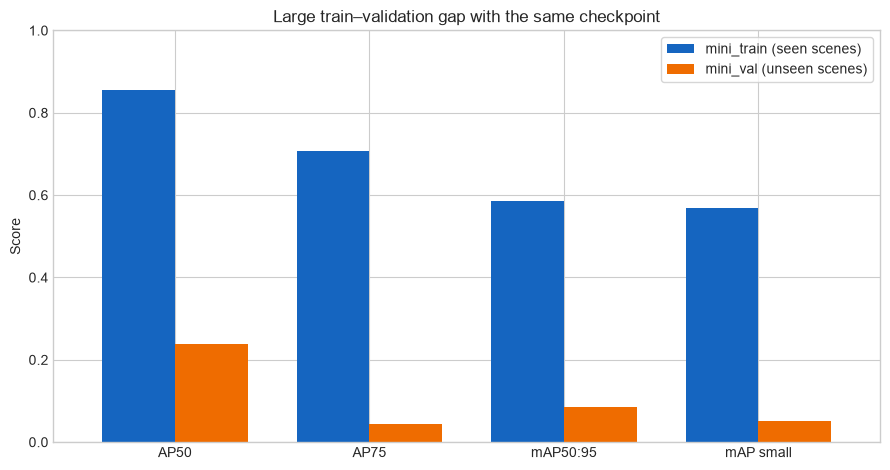

AP50 relative drop: 72.3%
mAP50:95 relative drop: 85.3%


In [7]:
comparison_metrics = {
    'AP50': 'ap50',
    'AP75': 'ap75',
    'mAP50:95': 'map_50_95',
    'mAP small': 'map_small',
}

generalization_table = pd.DataFrame(
    {
        'mini_train (seen scenes)': [
            training_results[key] for key in comparison_metrics.values()
        ],
        'mini_val (unseen scenes)': [
            validation_results[key] for key in comparison_metrics.values()
        ],
    },
    index=comparison_metrics.keys(),
)

# calculate the gap between the mini_train and mini_val
generalization_table['Absolute gap'] = (
    generalization_table['mini_train (seen scenes)']
    - generalization_table['mini_val (unseen scenes)']
)
display(generalization_table.style.format('{:.4f}'))

ax = generalization_table.iloc[:, :2].plot(
    kind='bar', figsize=(9, 4.8), width=0.75, color=['#1565c0', '#ef6c00']
)
ax.set(
    title='Large train–validation gap with the same checkpoint',
    xlabel='',
    ylabel='Score',
    ylim=(0.0, 1.0),
)
ax.legend(frameon=True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

ap50_relative_drop = 1.0 - validation_results['ap50'] / training_results['ap50']
map_relative_drop = 1.0 - validation_results['map_50_95'] / training_results['map_50_95']
print(f'AP50 relative drop: {ap50_relative_drop:.1%}')
print(f'mAP50:95 relative drop: {map_relative_drop:.1%}')


## 4. Radar fusion ablation

The Camera + Radar baseline reuses `validation_results` from Section 2. Only the radar-masked condition requires another inference pass:

- **Camera + Radar:** normal inference.
- **Radar masked:** every radar point is marked as padding, leaving only the learned null-radar token.


In [8]:
validation_dataset = NuScenesFrontLoader(
    dataroot=resolve_path(evaluation_config['dataroot']),
    split=evaluation_config['split'],
    image_size=config['image_size'],
    radar_channels=tuple(config['radar']['channels']),
    nsweeps=config['radar']['nsweeps'],
    camera_channel=config['camera_channel'],
    class_name=config['class_name'],
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=evaluation_config['batch_size'],
    shuffle=False,
    num_workers=evaluation_config['num_workers'],
    collate_fn=collate_fn,
    pin_memory=device.type == 'cuda',
)

model = CameraRadarDetector(image_size=config['image_size'], freeze_camera=True)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device).eval()

postprocessor = CenterNetPostProcessor(
    image_size=config['image_size'],
    score_threshold=evaluation_config['score_threshold'],
    top_k=evaluation_config['top_k'],
)

def make_metric():
    return PedestrianDetectionMetrics(
        iou_thresholds=evaluation_config['iou_thresholds'],
        report_iou_threshold=evaluation_config['report_iou_threshold'],
        report_score_threshold=evaluation_config['report_score_threshold'],
    )

radar_masked_metric = make_metric()

with torch.no_grad():
    for batch in validation_loader:
        images = batch['images'].to(device)
        radar_points = batch['radar_points'].to(device)
        radar_padding_mask = batch['radar_padding_mask'].to(device)
        all_radar_masked = torch.ones_like(radar_padding_mask) # mask all radar points as padding, so no radar token is used
        radar_masked_predictions = model(
            images, radar_points, all_radar_masked
        )
        radar_masked_metric.update(
            postprocessor(radar_masked_predictions), batch['targets']
        )

radar_masked_results = radar_masked_metric.compute()


,Camera + Radar,Radar masked,Absolute radar contribution
AP50,0.2371,0.2349,0.0022
AP75,0.0432,0.0445,-0.0013
mAP50:95,0.0863,0.0811,0.0053
Recall@0.1,0.3010,0.2943,0.0067


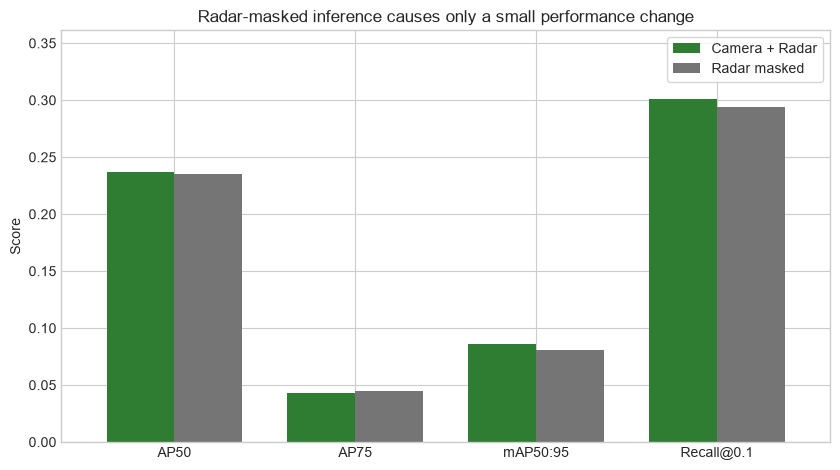

In [9]:
ablation_metrics = {
    'AP50': 'ap50',
    'AP75': 'ap75',
    'mAP50:95': 'map_50_95',
    'Recall@0.1': 'recall',
}
ablation_table = pd.DataFrame(
    {
        'Camera + Radar': [validation_results[key] for key in ablation_metrics.values()],
        'Radar masked': [
            radar_masked_results[key] for key in ablation_metrics.values()
        ],
    },
    index=ablation_metrics.keys(),
)
ablation_table['Absolute radar contribution'] = (
    ablation_table['Camera + Radar'] - ablation_table['Radar masked']
)
display(ablation_table.style.format('{:.4f}'))

ax = ablation_table.iloc[:, :2].plot(
    kind='bar', figsize=(8.5, 4.8), width=0.75, color=['#2e7d32', '#757575']
)
ax.set(
    title='Radar-masked inference causes only a small performance change',
    xlabel='',
    ylabel='Score',
    ylim=(0.0, max(0.30, float(ablation_table.iloc[:, :2].to_numpy().max()) * 1.2)),
)
ax.legend(frameon=True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Why the network can bypass radar

The fusion block uses a residual camera path:

```python
radar_update = cross_attention(camera_queries, radar_tokens)
fused_tokens = camera_tokens + radar_update
```

This is useful for robustness: if radar is missing or uninformative, the camera representation remains available. However, it also gives optimization an easy shortcut. The model may assign little weight to `radar_update`, attend to the null-radar token, and minimize the detection loss mainly through the camera path.

The decoder provides two additional camera-only skip paths:

```python
decoded_s8 = refine(upsampled_fused_s16 + camera_s8)
decoded_s4 = refine(upsampled_s8 + camera_s4)
```

Radar is fused only at the coarse `s16` level, while high-resolution `s8` and `s4` camera features enter the detector directly. The ablation result is therefore consistent with the architecture: the residual and skip paths support missing-modality operation, but they do not force the detector to exploit radar.


## Limitations

- nuScenes mini contains only eight training scenes and two validation scenes; the reported values are useful for prototype diagnosis but are not comparable to full nuScenes benchmark results.
- `mini_val` is used for model development and evaluation because mini does not provide a separate labeled test split.
- The radar-masked result measures dependency of this trained multimodal checkpoint; it does not measure the best achievable performance of a separately trained camera-only detector.
- The qualitative examples saved by the standard evaluator are the first configured samples, not a statistically balanced error sample.
